<a href="https://www.kaggle.com/code/tarzon/hr-analysis?scriptVersionId=75205447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<h1 style="background-color:ffffff;font-size:30px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:center">HR_Analysis Case Study</h1>


<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">Problem Statement</h1>

    Every year, Employees have promoted in the Several companies. Here we work on random dataset of a company.so we have the check employee is promoted or not?

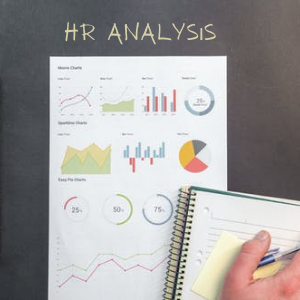

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">Introduction</h1>

In [ ]:
#Import Libraries
#set location
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

#        
import numpy as np       # linear algebra
import pandas as pd      # data processing, CSV file I/O (e.g. pd.read_csv)
import missingno as msno # 
        

# data visualization Libararies
import matplotlib.pyplot as plt 
import seaborn as sns 


#ML Libararies:
from sklearn.model_selection    import train_test_split
from sklearn.linear_model       import LinearRegression
from sklearn.linear_model       import LogisticRegression
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.linear_model       import SGDClassifier
from lightgbm                   import LGBMClassifier
from sklearn.metrics            import confusion_matrix,accuracy_score

Import Dataset

In [ ]:
train=pd.read_csv('../input/hranalysis/train.csv')
test=pd.read_csv('../input/hranalysis/test.csv')

In [ ]:
#Look at head of dataset
print("Train Head:\n", train.head())

print("\nTest Head:\n " ,test.head())

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">2.Perform Exploratory Data Analysis (EDA): Undersatanding dataset</h1>

In [ ]:
# check shape of Train & Test data
print('Train Shape:',train.shape)
print('Test Shape:',test.shape)

In [ ]:
# Dispaly information of Train data
train.info()


In [ ]:
#Dispaly information of Test data
test.info()

In [ ]:
#Display Discriptive Statistics of Train data
train.describe()

In [ ]:
#Display Discriptive Statistics of Test data
test.describe()

Pandas profiling
Pandas Profiling gives the overview of all the features we have used in the model. It gives how many missing values , unique valuesn there distinct count, memory size, Interactions,correlation between variables,mean , skewness, count, heatmap, visualization.

In [ ]:
import pandas_profiling
train.profile_report()

In [ ]:
#dispaly Correaltion between features through Heatmap : Lighter color Higher correlation (close to 1)
corr=train.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr,vmax=0.8,square=True,annot=True)

In [ ]:
#most corelated feature
n=14
col=corr.nlargest(n,'is_promoted')['is_promoted'].index
most_corr = pd.DataFrame(col)
most_corr.columns = ['Most Correlated Features']
most_corr

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left"> Univariate Analysis</h1>

In [ ]:
#visualize deaprtment in the company
plt.subplots(figsize=(15,5))
plt.title('Different Department in the company', fontsize = 20)
plt.xlabel('Department')
plt.ylabel('count')
train['department'].value_counts(dropna = False).plot.bar(color=['#459397','#63B4B8','#8FC8CB'])
plt.show()

In [ ]:
# checking the different regions of the company
plt.subplots(figsize=(15,5))
sns.countplot(train['region'], color = '#63B4B8')
plt.title('Different Regions in the company', fontsize = 20)
plt.xticks(rotation = 60)
plt.xlabel('Region Code')
plt.ylabel('count')
plt.show()

In [ ]:
#Display no of unique value with categories
education=train['education'].value_counts()
# plotting a pie chart of education lavels
plt.subplots(figsize=(8,8))
education.plot.pie(title='Pie Chart of the Employees Degrees', colors = ['#459397','#63B4B8','#8FC8CB'], shadow = True, autopct = "%.1f%%")
plt.show()

In [ ]:
# plotting a pie chart Representing gendergap
gender=train['gender'].value_counts()
gender.plot.pie(title='A Pie Chart Representing GenderGap',autopct="%.1f%%",colors = ["#54ACB0", "#83C3C6"])
plt.legend(title='Gender',labels=['Male','Female'],loc='upper right')
plt.show()

In [ ]:
plt.subplots(figsize=(15,5))
sns.countplot(x = 'education', data = train, hue = 'gender', palette = 'Paired')
plt.title('Showing Degree & Gender ratio', fontsize = 20)
plt.show()

In [ ]:
train['recruitment_channel'].value_counts()

In [ ]:
size = [30446, 23220,1142]
labels = "other", "sourcing",'referred'
colors = ['#459397','#63B4B8','#8FC8CB']
explode = [0.05,0.05,0.05]

plt.subplots(figsize=(8,8))
plt.pie(size, labels = labels, colors = colors, explode = explode, startangle=90, pctdistance=0.85, shadow = True, autopct = "%.2f%%")

#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('A Pie Chart Representing Recruitment_Channel', fontsize = 20)
plt.axis('off')
plt.legend(loc='upper right')
plt.show()

In [ ]:
train['no_of_trainings'].value_counts()

In [ ]:
# checking the 
plt.subplots(figsize=(10,5))
sns.stripplot(x=train['no_of_trainings'])
plt.title('no_of_trainings', fontsize = 20)
plt.show()

In [ ]:
plt.subplots(figsize=(15,5))
sns.distplot(train['age'])
plt.title('Distribution of Age of Employees', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('count')
plt.show()

In [ ]:
train['previous_year_rating'].value_counts().sort_values().plot.bar(color = 'lightblue', figsize = (15, 7))
plt.title('Distribution of Previous year rating of the Employees', fontsize = 20)
plt.xlabel('Ratings', fontsize = 15)
plt.ylabel('count')
plt.show()

In [ ]:
plt.subplots(figsize=(15,5))
sns.distplot(train['length_of_service'])
plt.title('showing of length_of_service of Employees', fontsize = 20)
plt.xlabel('length_of_service in year')
plt.ylabel('count')
plt.show()

In [ ]:
train['KPIs_met >80%'].value_counts()


In [ ]:
size = [35517, 19291]
labels = "Not Met KPI > 80%", "Met KPI > 80%"
colors = ["cyan", "lightblue"]
explode = [0, 0.1]

plt.rcParams['figure.figsize'] = (8, 8)
plt.pie(size, labels = labels, colors = colors, explode = explode, shadow = True, autopct = "%.2f%%",startangle=180)
plt.title('A Pie Chart Representing Gap in Employees in terms of KPI', fontsize = 20)
plt.axis('off')
plt.legend()
plt.show()

In [ ]:
train['awards_won?'].value_counts()


In [ ]:
plt.hist(train['awards_won?'])
plt.title('Display the gap of employee who win Awards or not', fontsize = 20)
plt.xlabel('0 -No_Awards_wonand 1- Awards_won', fontsize = 20)
plt.ylabel('count')
plt.show()

In [ ]:
train['avg_training_score'].value_counts()

In [ ]:
plt.subplots(figsize=(15,5))
sns.distplot(train['avg_training_score'])
plt.title('Distribution of Training Score among the Employees', fontsize = 20)
plt.xlabel('avg_training_score')
plt.ylabel('count')
plt.show()

In [ ]:
train['is_promoted'].value_counts()

In [ ]:
size = [50140, 4668]
labels = "Promoted == NO", "Promoted == YES"
colors = ['#459397','#8FC8CB']
explode = [0, 0.1]

#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.rcParams['figure.figsize'] = (8, 8)
plt.pie(size, labels = labels, colors = colors, explode = explode, shadow = True, autopct = "%.2f%%",startangle=180)
plt.title('Showing a Percentage of employees who Promoted ' , fontsize = 20)
plt.axis('off')
plt.legend()
plt.show()

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">Bivariate Analysis</h1>

In [ ]:
a=['department', 'region', 'education', 'gender', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?']

In [ ]:
for i in a:
  data = pd.crosstab(train[i],train['is_promoted'])
  data.div(data.sum(1).astype('float'), axis = 0).plot(kind = 'bar', stacked = True, figsize = (15, 5), color =  ['#459397','#8FC8CB'])

plt.legend()
plt.show()

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">Multivariate Analysis</h1>

In [ ]:
sns.barplot(x = "length_of_service", y = "is_promoted", hue = "gender",  data = train ) 

In [ ]:
sns.barplot(x = "no_of_trainings", y = "avg_training_score", hue = "is_promoted",  data = train,palette="Blues_d") 

In [ ]:
sns.barplot(x = "previous_year_rating", y = "KPIs_met >80%", hue = "is_promoted",  data = train,palette="Blues_d") 

In [ ]:
sns.barplot(x = "is_promoted", y = "education", hue = "gender",  data = train,palette="Blues_d") 

In [ ]:
sns.barplot(x = "department", y = "is_promoted", hue = "gender",  data = train,palette="Blues_d" ) 

In [ ]:
sns.scatterplot(data=train, x="age", y="length_of_service", hue="is_promoted")

In [ ]:
sns.scatterplot(data=train, x="no_of_trainings", y="avg_training_score", hue="is_promoted")

In [ ]:
sns.scatterplot(data=train, x="age", y="is_promoted", hue="gender")

In [ ]:
sns.scatterplot(data=train, x="department", y="age", hue="is_promoted")

In [ ]:
sns.scatterplot(data=train, x="department", y="age", hue="is_promoted")

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left"> 3.check duplicate row in train data if present</h1>

In [ ]:
def remove_duplicate(data):
  print("BEFOR REMOVING DUPLICATES - No of Row = " ,data.shape[0])
  data.drop_duplicates(keep='first',inplace=True)
  print("AFTER REMOVING DUPLICATES - No of Row = " ,data.shape[0])

  return 'checked Duplicates'

remove_duplicate(train) 

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">4.Check & Fill Missing value:</h1>

* Continuous: Mean/Meadian/Mode/Zero(specific value)
 
* Categorical: backfill/forward/other

In [ ]:
#Check the missing values in train data
train.isna().sum()

In [ ]:
#display of missing values in Train data
msno.bar(train, color = '#4CA0A5', figsize = (10,8)) 

In [ ]:
#Check the missing values in test data
test.isna().sum()

In [ ]:
#display of missing values in Test data
msno.bar(test, color = '#A5D3D6', figsize = (10,8))  

Missing values are present in "education" & "previous_year_rating " columns in both Train & Test data.

Let's Handle it based on intution.

Why missing data in 'previous_year_rating' cloumn?

data was no entered because these employees were Fresher.(lenght of service=1)
No datawould have been there in the datasource itself. Logically we are imputing with "0" as Fresher.

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">impute missing value</h1>

In [ ]:
train['previous_year_rating']=train['previous_year_rating'].fillna(0)
test['previous_year_rating']=test['previous_year_rating'].fillna(0)

In [ ]:
print (train['length_of_service'].head())
print(train['previous_year_rating'].head())

In [ ]:
train['Fresher']=train['previous_year_rating'].apply(lambda x: 'Fresher' if x==0 else 'Experienced')

In [ ]:
train[['previous_year_rating','length_of_service','Fresher']][train['Fresher']=='Fresher']

In [ ]:
train[['previous_year_rating','length_of_service','Fresher']].head(15)

Impute Missing data in 'Education' cloumn

we assume that wile collecting data Relevant menbers data were collected closed to one another.

1.ffill -> forward fill that fills Missing values with Previous Row value if Previous Row value is NAN, moves to the next element without imputing any value.

2.bfill -> backword fill thaat fills Missing values with Next Row value Next Row value is NAN, moves to the next element without imputing any any value.

In [ ]:
train['education']=train['education'].ffill(axis=0)
train['education']=train['education'].bfill(axis=0)

test['education']=test['education'].ffill(axis=0)
test['education']=test['education'].bfill(axis=0)

In [ ]:
display("Null value in Train data:",train.isna().sum())
display("Null value in Test data:",test.isna().sum())

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">5. Drop unneccessary columns in both Train & test data</h1>

In [ ]:
train=train.drop(['employee_id'],axis=1)
test=test.drop(['employee_id'],axis=1)

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">6.split dataset into Predictors(independent) & Target(dependent)</h1>

In [ ]:
xtrain=train[['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score']]
ytrain=train['is_promoted']
xtest=test

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">7. Data Encoding : Label Encoding, Onehot encoding</h1>

In [ ]:
def data_encode(endcode_strategy,encode_col,encode_data):
    if endcode_strategy=='Label_Encoding':
        print('Label_Encoding')
        Encoder==Labelencoder()
        for col in encode_col:
            print("columns",col)
            encode_data(col)==Encoder.fit_transform(tuple(encode_data[col]))
    elif endcode_strategy=='Onehot_Encoding':
        print('Onehot_Encoding')
        encode_data=pd.get_dummies(encode_data)  
        
    dtype_list=['float64','float32','int64','int32']
    encode_data.astype(dtype_list[0]).dtypes
    
    return encode_data

In [ ]:
encode_col=['department','region', 'education', 'gender', 'recruitment_channel','age']
endcode_strategy=['Label_Encoding','Onehot_Encoding']

xtrain_encode=data_encode(endcode_strategy[1],encode_col,xtrain)
xtest_encode=data_encode(endcode_strategy[1],encode_col,xtest)

In [ ]:
xtrain=xtrain_encode
xtrain.head()

In [ ]:
xtest=xtest_encode
display(xtest_encode.head())

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">8. Model Building</h1>

In [ ]:
#Linear Regression 
lin=LinearRegression()
lin.fit(xtrain,ytrain)

ypred=lin.predict(xtest)

print("Training Accuracy :", lin.score(xtrain, ytrain))

In [ ]:
#LogisticRegression
log = LogisticRegression(random_state=15)
log.fit(xtrain,ytrain)

ypred=log.predict(xtest)

print("Training Accuracy :", log.score(xtrain, ytrain))

In [ ]:
#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(xtrain, ytrain)

ypred = knn.predict(xtest)

print("Training Accuracy :", knn.score(xtrain, ytrain))

In [ ]:
#Decision tree
dtc = DecisionTreeClassifier(max_depth = 5,random_state=25)
dtc.fit(xtrain, ytrain)

ypred = dtc.predict(xtest)
print("Training Accuracy :", dtc.score(xtrain, ytrain))

In [ ]:
#Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(xtrain, ytrain)

ypred = gnb.predict(xtest)

print("Training Accuracy :", gnb.score(xtrain, ytrain))

In [ ]:
#Light Gradient Boosting Classifier

lgb = LGBMClassifier()
lgb.fit(xtrain, ytrain)

ypred = lgb.predict(xtest)

print("Training Accuracy :", lgb.score(xtrain, ytrain))

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align:left">Thank you for Reading!!  
    
  Don't forget to appreciate me with an Upvote and Comments.  </h1>
